In [3]:
import pandas as pd
import numpy as np

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [4]:
DATA_PATH = "../02_data_processed/TCGA_LUAD_top2000_logCPM_samplesxgenes.csv"

X = pd.read_csv(DATA_PATH, index_col=0)

print("Data shape:", X.shape)

Data shape: (540, 2000)


In [5]:
# correlation distance
dist_matrix = pdist(X, metric="correlation")

print("Distance matrix length:", len(dist_matrix))

Distance matrix length: 145530


In [6]:
Z = linkage(dist_matrix, method="average")
print("Linkage matrix shape:", Z.shape)

Linkage matrix shape: (539, 4)


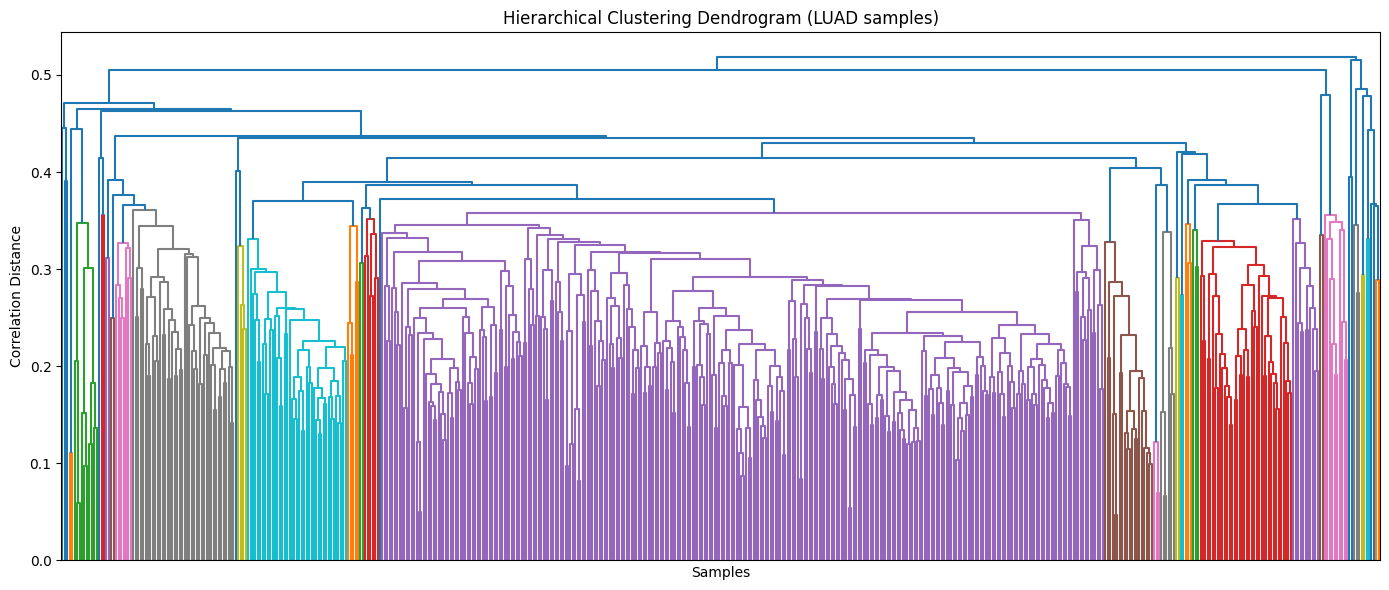

In [7]:
plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (LUAD samples)")
plt.xlabel("Samples")
plt.ylabel("Correlation Distance")
plt.tight_layout()
plt.show()

In [8]:
results = {}

for k in [2, 3, 4]:
    labels = fcluster(Z, k, criterion="maxclust")
    sil = silhouette_score(X, labels, metric="correlation")
    results[k] = sil
    print(f"k={k}, silhouette={sil:.4f}")

k=2, silhouette=0.2379
k=3, silhouette=0.2067
k=4, silhouette=0.1897


In [9]:
best_k = max(results, key=results.get)
print("Best k:", best_k)

final_labels = fcluster(Z, best_k, criterion="maxclust")

cluster_df = pd.DataFrame({
    "sample_id": X.index,
    "cluster": final_labels
})

OUT_CLUSTER = "../02_data_processed/TCGA_LUAD_cluster_assignment.csv"
cluster_df.to_csv(OUT_CLUSTER, index=False)

cluster_df["cluster"].value_counts()


Best k: 2


cluster
1    527
2     13
Name: count, dtype: int64

karena cluster nya kecil cuman 13, biar ga dikira outlier maka kita validasi cluster kecil

In [11]:
# add label ke data
X_labeled = X.copy()
X_labeled["cluster"] = final_labels

# hitung centroid tiap cluster
centroids = X_labeled.groupby("cluster").mean()

# distance rata-rata tiap sampel ke centroid clusternya
from scipy.spatial.distance import cdist

dist_to_centroid = []

for i, row in X.iterrows():
    cl = final_labels[list(X.index).index(i)]
    centroid = centroids.loc[cl].values
    d = cdist([row.values], [centroid], metric="correlation")[0][0]
    dist_to_centroid.append(d)

X_labeled["dist_to_centroid"] = dist_to_centroid

X_labeled.groupby("cluster")["dist_to_centroid"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
1,527.0,0.218950,0.067769,0.092637,0.167507,0.205015,0.256317,0.440290
2,13.0,0.245406,0.032692,0.193227,0.230064,0.249301,0.262091,0.303355


In [12]:
labels_k3 = fcluster(Z, 3, criterion="maxclust")
pd.Series(labels_k3).value_counts()

1    527
3     11
2      2
Name: count, dtype: int64